In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create Sample Accident Dataset
np.random.seed(42)
n = 1000

df = pd.DataFrame({
    'Time_of_Day': np.random.choice(['Morning','Afternoon','Evening','Night'], n),
    'Weather': np.random.choice(['Clear','Rain','Fog','Snow'], n),
    'Road_Condition': np.random.choice(['Dry','Wet','Icy','Snowy'], n),
    'Severity': np.random.choice(['Low','Medium','High'], n),
    'Accidents': np.random.randint(1, 50, n)
})

print(df.head())
print(df.shape)

  Time_of_Day Weather Road_Condition Severity  Accidents
0     Evening    Rain            Icy   Medium         36
1       Night     Fog          Snowy   Medium         12
2     Morning   Clear            Wet      Low         17
3     Evening   Clear          Snowy      Low         39
4     Evening   Clear          Snowy   Medium          9
(1000, 5)


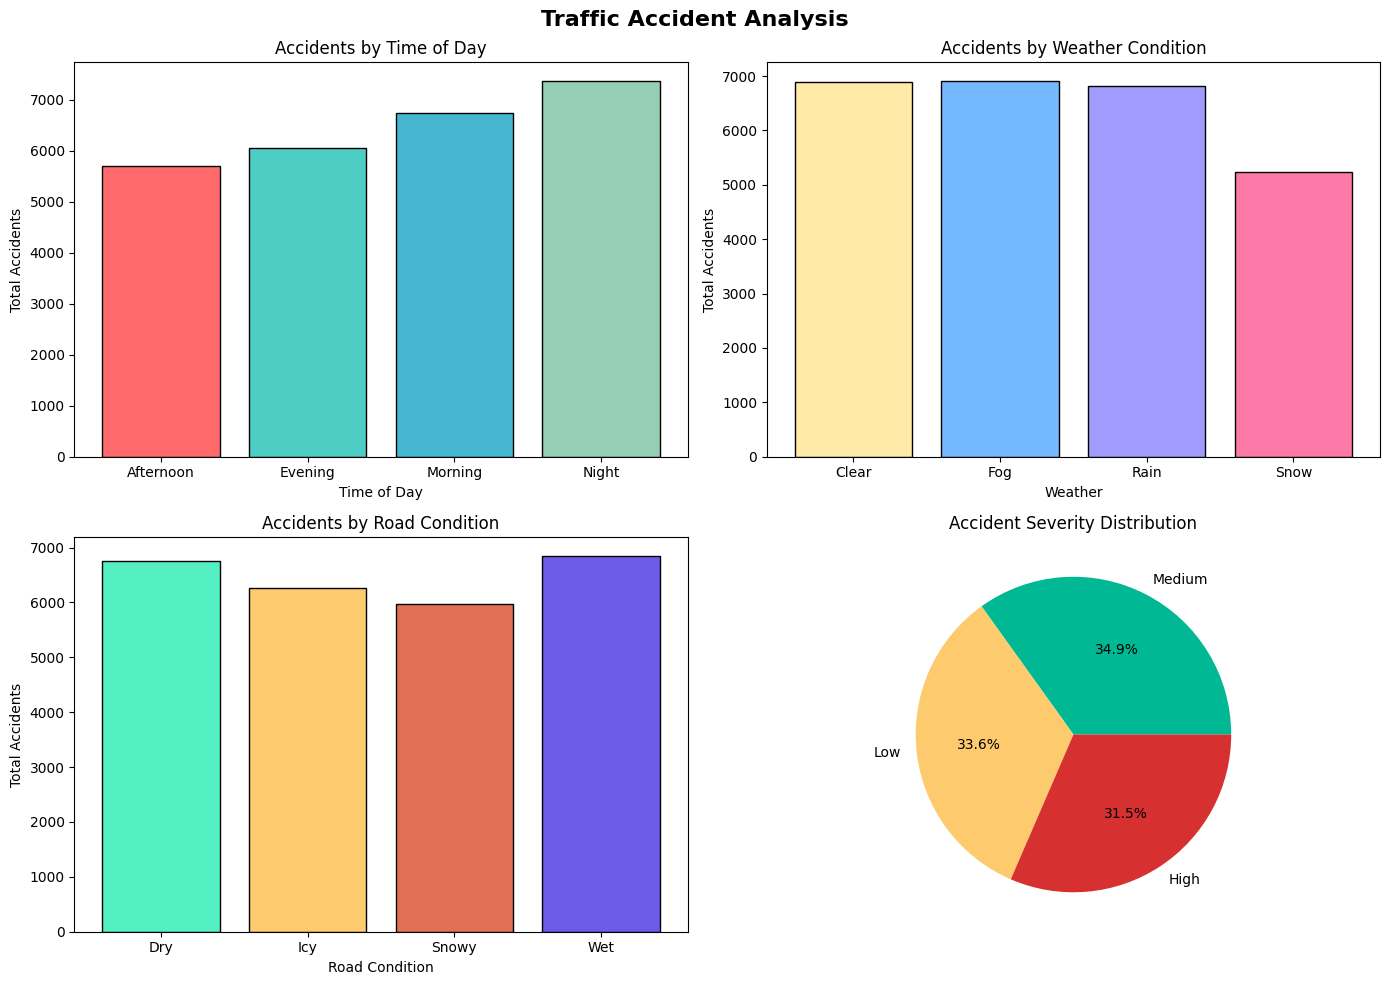

Saved!


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Traffic Accident Analysis',
             fontsize=16, fontweight='bold')

# Chart 1: Accidents by Time of Day
time_data = df.groupby('Time_of_Day')['Accidents'].sum()
axes[0,0].bar(time_data.index, time_data.values,
              color=['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4'],
              edgecolor='black')
axes[0,0].set_title('Accidents by Time of Day')
axes[0,0].set_xlabel('Time of Day')
axes[0,0].set_ylabel('Total Accidents')

# Chart 2: Accidents by Weather
weather_data = df.groupby('Weather')['Accidents'].sum()
axes[0,1].bar(weather_data.index, weather_data.values,
              color=['#FFEAA7','#74B9FF','#A29BFE','#FD79A8'],
              edgecolor='black')
axes[0,1].set_title('Accidents by Weather Condition')
axes[0,1].set_xlabel('Weather')
axes[0,1].set_ylabel('Total Accidents')

# Chart 3: Accidents by Road Condition
road_data = df.groupby('Road_Condition')['Accidents'].sum()
axes[1,0].bar(road_data.index, road_data.values,
              color=['#55EFC4','#FDCB6E','#E17055','#6C5CE7'],
              edgecolor='black')
axes[1,0].set_title('Accidents by Road Condition')
axes[1,0].set_xlabel('Road Condition')
axes[1,0].set_ylabel('Total Accidents')

# Chart 4: Accidents by Severity
severity_data = df['Severity'].value_counts()
axes[1,1].pie(severity_data.values,
              labels=severity_data.index,
              autopct='%1.1f%%',
              colors=['#00B894','#FDCB6E','#D63031'])
axes[1,1].set_title('Accident Severity Distribution')

plt.tight_layout()
plt.savefig('SCT_DS_4.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

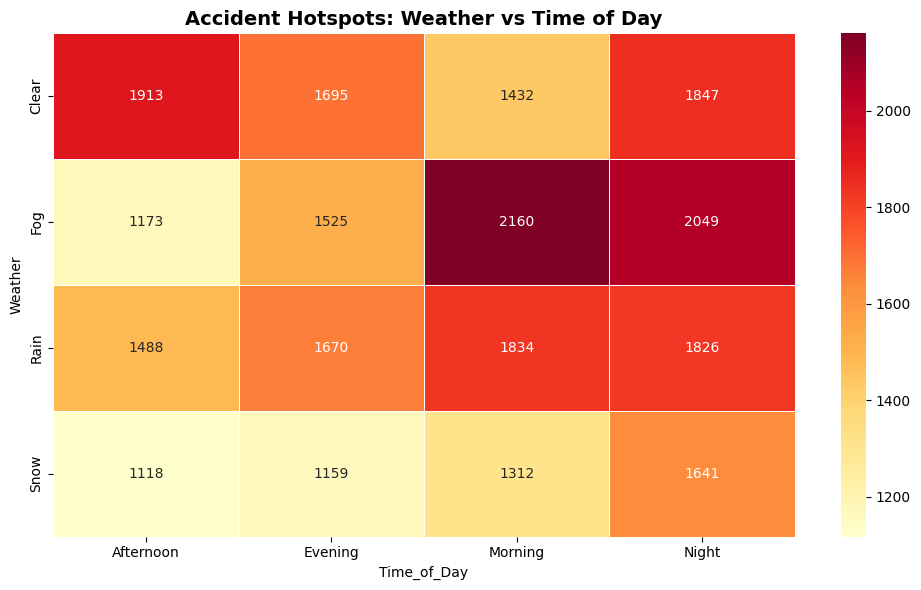

Heatmap Saved!


In [19]:
# Heatmap - Accident Hotspots
pivot = df.pivot_table(values='Accidents',
                        index='Weather',
                        columns='Time_of_Day',
                        aggfunc='sum')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.0f',
            cmap='YlOrRd', linewidths=0.5)
plt.title('Accident Hotspots: Weather vs Time of Day',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('SCT_DS_4_heatmap.png', dpi=150)
plt.show()
print("Heatmap Saved!")